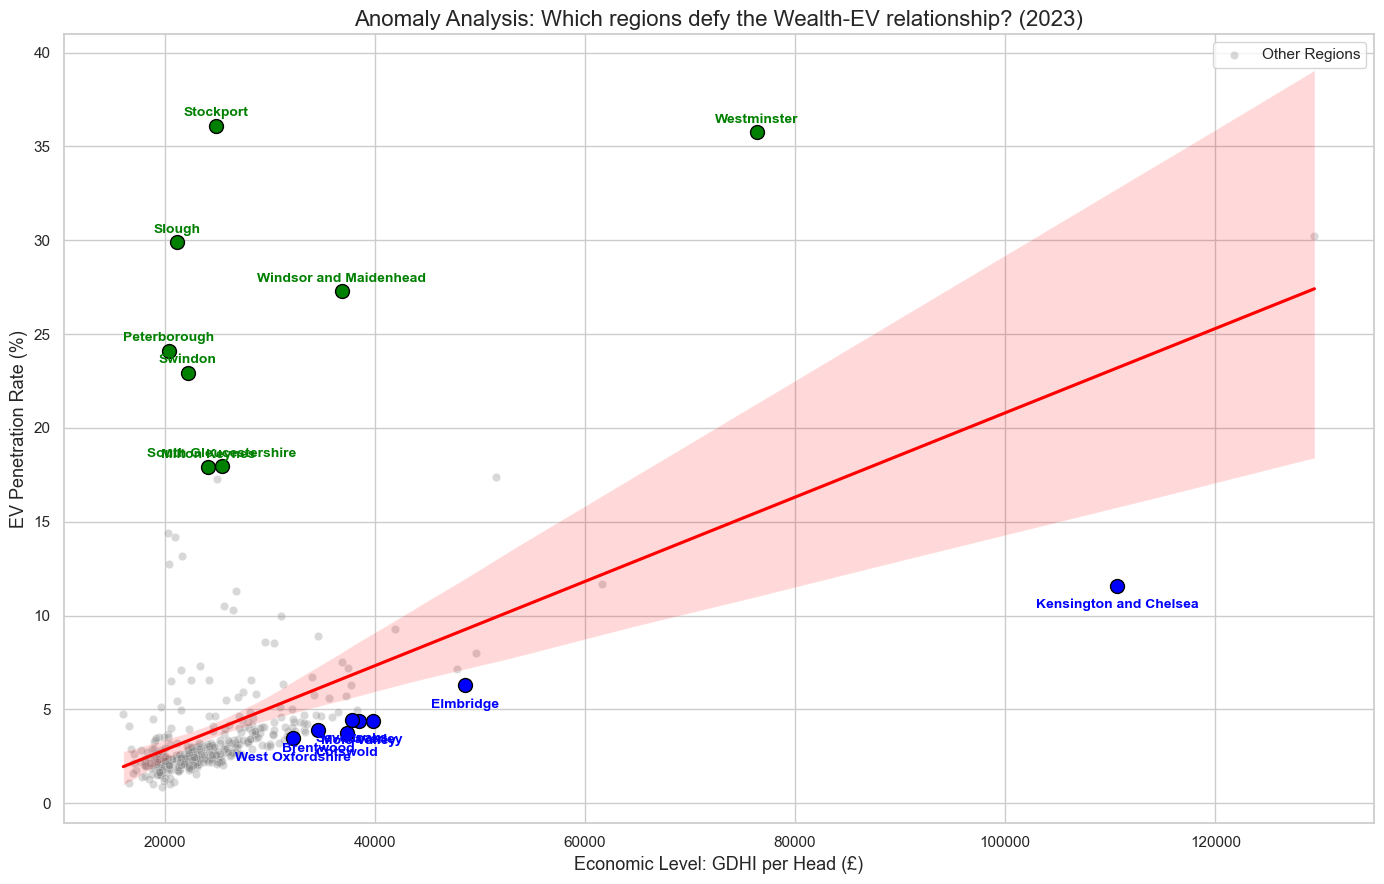

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

# 1. 加载数据
file_path = 'Master_Panel_Data_Final.csv'
df = pd.read_csv(file_path)

# 2. 数据清洗与筛选
# 使用 2023 年数据（这是目前 GDHI 和 EV 数据最完整的重合年份）
# 仅分析地方政府级别 (LAD)
df_2023 = df[(df['Geo_level'] == 'LAD') & (df['year'] == 2023)].copy()
df_2023 = df_2023.dropna(subset=['ev_penetration', 'gdhi_per_head'])

# 3. 建立线性回归模型：用 GDHI 预测 EV 渗透率
X = sm.add_constant(df_2023['gdhi_per_head']) # 添加截距项
model = sm.OLS(df_2023['ev_penetration'], X).fit()

# 计算残差 (Residual = 实际渗透率 - 预测渗透率)
# 正残差表示表现超前，负残差表示表现滞后
df_2023['residual'] = model.resid

# 4. 识别异常地区
# 选出残差最大（表现最突出）和最小（表现最滞后）的前 8 个地区
top_outliers = df_2023.sort_values(by='residual', ascending=False).head(8)
bottom_outliers = df_2023.sort_values(by='residual', ascending=True).head(8)

# 5. 可视化绘制
plt.figure(figsize=(14, 9))
sns.set_theme(style="whitegrid")

# 绘制所有地区的背景散点
sns.scatterplot(data=df_2023, x='gdhi_per_head', y='ev_penetration', 
                alpha=0.3, color='grey', label='Other Regions')

# 绘制回归线（图中那条红色的趋势线）
sns.regplot(data=df_2023, x='gdhi_per_head', y='ev_penetration', 
            scatter=False, color='red', line_kws={"label":"Expected Trend (Wealth-driven)"})

# 标注并高亮：表现超前的地区（绿色）
for i, row in top_outliers.iterrows():
    plt.scatter(row['gdhi_per_head'], row['ev_penetration'], color='green', s=100, edgecolors='black')
    plt.text(row['gdhi_per_head'], row['ev_penetration']+0.5, row['ONS_geo'], 
             color='green', fontsize=10, fontweight='bold', ha='center')

# 标注并高亮：表现滞后的地区（蓝色）
for i, row in bottom_outliers.iterrows():
    plt.scatter(row['gdhi_per_head'], row['ev_penetration'], color='blue', s=100, edgecolors='black')
    plt.text(row['gdhi_per_head'], row['ev_penetration']-1.2, row['ONS_geo'], 
             color='blue', fontsize=10, fontweight='bold', ha='center')

# 图表美化
plt.title('Anomaly Analysis: Which regions defy the Wealth-EV relationship? (2023)', fontsize=16)
plt.xlabel('Economic Level: GDHI per Head (£)', fontsize=13)
plt.ylabel('EV Penetration Rate (%)', fontsize=13)
plt.legend()
plt.tight_layout()

